<a href="https://colab.research.google.com/github/sc-mari-a/Qualification-work/blob/main/Thesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Датасет

In [1]:
import kagglehub
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

## Огляд датасету

In [2]:
path = kagglehub.dataset_download("umuttuygurr/e-commerce-fraud-detection-dataset")
file_path = f"{path}/transactions.csv"
full_df = pd.read_csv(file_path)

total_count = len(full_df)
fraud_count = len(full_df[full_df['is_fraud'] == 1])
fraud_percentage = (fraud_count / total_count) * 100

print(f"Розмір датасету: {total_count}")
print(f"Кількість шахрайства: {fraud_count}")
print(f"Відсоток шахрайства: {fraud_percentage:.4f}%")

Using Colab cache for faster access to the 'e-commerce-fraud-detection-dataset' dataset.
Розмір датасету: 299695
Кількість шахрайства: 6612
Відсоток шахрайства: 2.2062%


In [3]:
full_df.head()

,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,0,1,1,1,2024-01-06T04:09:39Z,370.95,0
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,2024-01-09T20:13:47Z,149.62,0
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,2024-01-12T06:20:11Z,164.08,0
3,4,1,141,47,147.93,112.47,FR,FR,web,fashion,0,1,1,1,2024-01-15T17:00:04Z,397.40,0
4,5,1,141,47,147.93,132.91,FR,US,web,electronics,0,1,1,1,2024-01-17T01:27:31Z,935.28,0


In [4]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299695 entries, 0 to 299694
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           299695 non-null  int64  
 1   user_id                  299695 non-null  int64  
 2   account_age_days         299695 non-null  int64  
 3   total_transactions_user  299695 non-null  int64  
 4   avg_amount_user          299695 non-null  float64
 5   amount                   299695 non-null  float64
 6   country                  299695 non-null  object 
 7   bin_country              299695 non-null  object 
 8   channel                  299695 non-null  object 
 9   merchant_category        299695 non-null  object 
 10  promo_used               299695 non-null  int64  
 11  avs_match                299695 non-null  int64  
 12  cvv_result               299695 non-null  int64  
 13  three_ds_flag            299695 non-null  int64  
 14  tran

In [5]:
# все шахрайство і рандомний відбір 113к - sample(n=113388
fraud_cases = full_df[full_df['is_fraud'] == 1]
normal_cases = full_df[full_df['is_fraud'] == 0].sample(n=113388, random_state=42)

# об'єднуємо та перемішуємо
df = pd.concat([fraud_cases, normal_cases])

print(f"Новий розмір датасету: {len(df)}")
print(f"Кількість шахрайства: {df['is_fraud'].sum()}")
print(f"Відсоток шахрайства: {round(df['is_fraud'].mean()*100, 2)}%")

Новий розмір датасету: 120000
Кількість шахрайства: 6612
Відсоток шахрайства: 5.51%


In [6]:
df.isnull().sum()

,0
transaction_id,0
user_id,0
account_age_days,0
total_transactions_user,0
avg_amount_user,0
amount,0
country,0
bin_country,0
channel,0
merchant_category,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
# перелік і кількість унікальних значень для кожного стовпця
for col in df.columns:
    print(f"{col}: {df[col].unique()}")
    print(f'{col}: {len(df[col].unique())}')
    print()

transaction_id: [   115    116    455 ...  82425   4129 178229]
transaction_id: 120000

user_id: [   3   10   13 ... 5953   63  276]
user_id: 6000

account_age_days: [ 954 1742 1532 ... 1206  115  722]
account_age_days: 1801

total_transactions_user: [40 54 41 52 47 51 59 56 57 49 42 44 53 43 45 46 55 48 58 60 50]
total_transactions_user: 21

avg_amount_user: [172.03 154.87 114.66 ... 137.54  88.27  43.97]
avg_amount_user: 5347

amount: [ 155.12    4.08 1362.57 ...  800.23  356.19  522.88]
amount: 41173

country: ['TR' 'US' 'IT' 'GB' 'ES' 'FR' 'PL' 'DE' 'NL' 'RO']
country: 10

bin_country: ['DE' 'TR' 'US' 'IT' 'GB' 'RO' 'ES' 'NL' 'PL' 'FR']
bin_country: 10

channel: ['web' 'app']
channel: 2

merchant_category: ['electronics' 'fashion' 'gaming' 'grocery' 'travel']
merchant_category: 5

promo_used: [0 1]
promo_used: 2

avs_match: [0 1]
avs_match: 2

cvv_result: [0 1]
cvv_result: 2

three_ds_flag: [1 0]
three_ds_flag: 2

transaction_time: ['2024-03-30T09:55:57Z' '2024-04-13T08:22:02Z' '20

1. **transaction_id** - унікальний номер транзакції
2. **user_id** - унікальний номер користувача (кожен з них у середньому робить 40–60 покупок).
3. **account_age_days** - скільки днів пройшло з моменту створення акаунта користувача.
4. **total_transactions_user** - загальна кількість операцій (покупок), які зробив цей користувач за весь час.
5. **avg_amount_user** - середня сума, яку цей користувач зазвичай витрачає за один раз.
6. **amount** - сума конкретної покупки в доларах.

7. **country** - країна, в якій знаходиться користувач.

8. **bin_country** - країна банку, який випустив картку, якою розраховуються.

9. **channel** - як саме робили покупку: через вебсайт (web) чи мобільний додаток (app).

10. **merchant_category** - категорія товару чи послуги (електроніка, одяг, продукти, ігри, подорожі і тд.).

11. **promo_used** - чи використовував покупець промокод або знижку (1 — так, 0 — ні).

12. **avs_match** - чи збігається введена адреса покупця з адресою, до якої прив'язана його картка (1 — збігається, 0 — не збігається).

13. **cvv_result** - чи правильно введено захисний тризначний код (CVV) зі зворотної сторони картки (1 — правильно, 0 — помилка).

14. **three_ds_flag** - чи була включена додаткова перевірка безпеки платежу, наприклад, підтвердження через код у SMS (1 — так, 0 — ні).

15. **transaction_time** - точний час та дата, коли була здійснена покупка.

16. **shipping_distance_km** - відстань у кілометрах між адресою платника та адресою, куди доставляють товар.

17. **is_fraud** - чи є ця операція шахрайською (1 — це шахрайство, 0 — звичайна безпечна покупка).


## Обробка датасету

In [9]:
df = df.sort_values(['user_id', 'transaction_time'])

In [10]:
# КАТЕГОРІЇ
le = LabelEncoder()
df['category_enc'] = le.fit_transform(df['merchant_category'])

# окремий бінарний стовпець для кожного значення категорії
categorical_cols = ['channel', 'merchant_category']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [11]:
# СУМА
# відношення суми до середньої суми користувача
df['amount_relative_to_avg'] = df['amount'] / (df['avg_amount_user'])
# відношення суми до медіанної суми користувача
user_median = df.groupby('user_id')['amount'].transform('median')
df['amount_to_median_ratio'] = df['amount'] / (user_median)
# відношення відстані до суми
df['high_dist_low_amount'] = df['shipping_distance_km'] / (df['amount'] + 1)

In [12]:
# ЧАС
# перетворення тип часу
df['transaction_time'] = pd.to_datetime(df['transaction_time'])
# година
df['hour'] = df['transaction_time'].dt.hour
# день тижня
df['day_of_week'] = df['transaction_time'].dt.dayofweek
# ніч
df['is_night'] = df['hour'].apply(lambda x: 1 if x <= 5 else 0)
# циклічне кодування часу
df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)

In [13]:
# ГЕОГРАФІЯ
# чи випущена карта в іншій країні, ніж країна транзакції
df['is_foreign_card'] = (df['country'] != df['bin_country']).astype(int)
# поєднання іноземної карти та великої відстані доставки
df['foreign_dist_risk'] = df['is_foreign_card'] * df['shipping_distance_km']
# відхилення відстані доставки від середньої по датасету
df['distance_z_score'] = (df['shipping_distance_km'] - df['shipping_distance_km'].mean()) / df['shipping_distance_km'].std()

In [14]:
# ШВИДКІСТЬ ТРАНЗАКЦІЙ
# час з моменту попередньої транзакції
df['time_since_last_tx'] = df.groupby('user_id')['transaction_time'].diff().dt.total_seconds().fillna(-1)
# транзакції менше 30 сек
df['is_rapid_transaction'] = (df['time_since_last_tx'].between(0, 300)).astype(int)

In [15]:
# АКАУНТ
# Логарифм віку акаунта
df['account_age_risk'] = np.log1p(df['account_age_days'])
# провали AVS та CVV
df['security_check_failed'] = ((df['avs_match'] == 0) & (df['cvv_result'] == 0)).astype(int)

In [16]:
# Агрегації через Rolling Windows (Часові вікна)
df.set_index('transaction_time', inplace=True)
# кількість транзакцій за останню годину
df['velocity_1h'] = df.groupby('user_id')['amount'].rolling('1h').count().reset_index(0, drop=True)
# сума витрат за останні 24 години
df['cum_amount_24h'] = df.groupby('user_id')['amount'].rolling('24h').sum().reset_index(0, drop=True)
# кількість транзакцій за останні десять хвилин
df['tx_count_10m'] = df.groupby('user_id')['amount'].rolling('10min').count().reset_index(0, drop=True)
# середня сума покупок за останню добу
df['avg_amount_24h'] = df.groupby('user_id')['amount'].rolling('24h').mean().reset_index(0, drop=True)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 120000 entries, 2024-01-06 04:09:39+00:00 to 2024-10-30 11:10:23+00:00
Data columns (total 39 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   transaction_id             120000 non-null  int64  
 1   user_id                    120000 non-null  int64  
 2   account_age_days           120000 non-null  int64  
 3   total_transactions_user    120000 non-null  int64  
 4   avg_amount_user            120000 non-null  float64
 5   amount                     120000 non-null  float64
 6   country                    120000 non-null  object 
 7   bin_country                120000 non-null  object 
 8   promo_used                 120000 non-null  int64  
 9   avs_match                  120000 non-null  int64  
 10  cvv_result                 120000 non-null  int64  
 11  three_ds_flag              120000 non-null  int64  
 12  shipping_distance_km       120000 non-nu

In [18]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [19]:
pd.set_option('display.max_columns', None)
df.head()

,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,is_fraud,category_enc,channel_web,merchant_category_fashion,merchant_category_gaming,merchant_category_grocery,merchant_category_travel,amount_relative_to_avg,amount_to_median_ratio,high_dist_low_amount,hour,day_of_week,is_night,hour_sin,hour_cos,is_foreign_card,foreign_dist_risk,distance_z_score,time_since_last_tx,is_rapid_transaction,account_age_risk,security_check_failed,velocity_1h,cum_amount_24h,tx_count_10m,avg_amount_24h
transaction_time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-06 04:09:39+00:00,1,1,141,47,147.93,84.75,FR,FR,0,1,1,1,370.95,0,4,1,0,0,0,1,0.572906,0.553415,4.325948,4,5,1,0.866025,0.500000,0,0.00,-0.027159,-1.0,0,4.955827,0,1.0,84.75,1.0,84.75
2024-01-17 01:27:31+00:00,5,1,141,47,147.93,132.91,FR,US,0,1,1,1,935.28,0,0,1,0,0,0,0,0.898465,0.867899,6.984393,1,2,1,0.258819,0.965926,1,935.28,1.134802,940672.0,0,4.955827,0,1.0,132.91,1.0,132.91
2024-01-30 00:51:41+00:00,7,1,141,47,147.93,125.98,FR,FR,0,1,1,1,443.75,0,0,0,0,0,0,0,0.851619,0.822646,3.494645,0,1,1,0.000000,1.000000,0,0.00,0.122737,1121050.0,0,4.955827,0,1.0,125.98,1.0,125.98
2024-03-19 08:53:32+00:00,12,1,141,47,147.93,184.93,FR,FR,0,0,0,1,323.16,0,3,0,0,0,1,0,1.250118,1.207588,1.738073,8,1,0,0.866025,-0.500000,0,0.00,-0.125559,4262511.0,0,4.955827,1,1.0,184.93,1.0,184.93
2024-03-20 21:47:22+00:00,13,1,141,47,147.93,163.45,FR,FR,0,1,1,1,398.80,0,4,0,0,0,0,1,1.104914,1.067324,2.425053,21,2,0,-0.707107,0.707107,0,0.00,0.030184,132830.0,0,4.955827,0,1.0,163.45,1.0,163.45


In [20]:
# видаляємо стовпці
df = df.drop(['transaction_id', 'user_id', 'country', 'bin_country'], axis=1)

In [21]:
print(f"кількість стовпців: {len(df.columns)}")
print(df.columns.tolist())

кількість стовпців: 35
['account_age_days', 'total_transactions_user', 'avg_amount_user', 'amount', 'promo_used', 'avs_match', 'cvv_result', 'three_ds_flag', 'shipping_distance_km', 'is_fraud', 'category_enc', 'channel_web', 'merchant_category_fashion', 'merchant_category_gaming', 'merchant_category_grocery', 'merchant_category_travel', 'amount_relative_to_avg', 'amount_to_median_ratio', 'high_dist_low_amount', 'hour', 'day_of_week', 'is_night', 'hour_sin', 'hour_cos', 'is_foreign_card', 'foreign_dist_risk', 'distance_z_score', 'time_since_last_tx', 'is_rapid_transaction', 'account_age_risk', 'security_check_failed', 'velocity_1h', 'cum_amount_24h', 'tx_count_10m', 'avg_amount_24h']


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 120000 entries, 2024-01-06 04:09:39+00:00 to 2024-10-30 11:10:23+00:00
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   account_age_days           120000 non-null  int64  
 1   total_transactions_user    120000 non-null  int64  
 2   avg_amount_user            120000 non-null  float64
 3   amount                     120000 non-null  float64
 4   promo_used                 120000 non-null  int64  
 5   avs_match                  120000 non-null  int64  
 6   cvv_result                 120000 non-null  int64  
 7   three_ds_flag              120000 non-null  int64  
 8   shipping_distance_km       120000 non-null  float64
 9   is_fraud                   120000 non-null  int64  
 10  category_enc               120000 non-null  int64  
 11  channel_web                120000 non-null  int64  
 12  merchant_category_fashion  120000 non-nu

In [23]:
# 80% перших записів - навчання, 20% останніх - тест
split_point = int(len(df) * 0.8)

train_df = df.iloc[:split_point]
test_df = df.iloc[split_point:]

X_train = train_df.drop(['is_fraud'], axis=1)
y_train = train_df['is_fraud']

X_test = test_df.drop(['is_fraud'], axis=1)
y_test = test_df['is_fraud']

print(f"Розмір train: {len(X_train)}")
print(f"Кількість шахрайства: {len(y_train[y_train == 1])}")
print(f"Відсоток шахрайства: {len(y_train[y_train == 1])/len(X_train)*100:.4f}%")
print()
print(f"Розмір test: {len(X_test)}")
print(f"Кількість шахрайства: {len(y_test[y_test == 1])}")
print(f"Відсоток шахрайства: {len(y_test[y_test == 1])/len(X_test)*100:.4f}%")

Розмір train: 96000
Кількість шахрайства: 5277
Відсоток шахрайства: 5.4969%

Розмір test: 24000
Кількість шахрайства: 1335
Відсоток шахрайства: 5.5625%


# Методи

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier

## LOGISTIC REGRESSION

In [25]:
a = ['security_check_failed', 'shipping_distance_km', 'foreign_dist_risk',
     'high_dist_low_amount', 'amount_relative_to_avg', 'amount_to_median_ratio',
     'cum_amount_24h', 'is_foreign_card', 'channel_web', 'promo_used', 'hour',
     'velocity_1h', 'is_night', 'hour_sin', 'merchant_category_fashion',
     'tx_count_10m', 'day_of_week', 'merchant_category_gaming', 'three_ds_flag',
     'merchant_category_grocery', 'time_since_last_tx','account_age_days',
     'cvv_result', 'avs_match', 'account_age_risk']

X_train_LR = X_train[a]
X_test_LR = X_test[a]

scaler = StandardScaler()
X_train_scaled_LR = scaler.fit_transform(X_train_LR)
X_test_scaled_LR = scaler.transform(X_test_LR)

In [26]:
# Навчання
lr_model = LogisticRegression(class_weight={0:1, 1:4}, max_iter=100, random_state=42)
lr_model.fit(X_train_scaled_LR, y_train)

# Прогноз
lr_pred = lr_model.predict(X_test_scaled_LR)

In [27]:
# Оцінка
print("РЕЗУЛЬТАТИ Logistic Regression")
print("\nМатриця помилок:")
print(confusion_matrix(y_test, lr_pred))

print("\nЗвіт класифікації:")
print(classification_report(y_test, lr_pred))

РЕЗУЛЬТАТИ Logistic Regression

Матриця помилок:
[[22186   479]
 [  288  1047]]

Звіт класифікації:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98     22665
           1       0.69      0.78      0.73      1335

    accuracy                           0.97     24000
   macro avg       0.84      0.88      0.86     24000
weighted avg       0.97      0.97      0.97     24000



## PCA

In [28]:
b = ['security_check_failed', 'distance_z_score', 'shipping_distance_km', 'hour',
     'foreign_dist_risk', 'high_dist_low_amount', 'amount_relative_to_avg',
     'amount_to_median_ratio', 'amount', 'avg_amount_24h', 'cum_amount_24h',
     'is_foreign_card', 'merchant_category_travel', 'hour_cos', 'is_night',
     'hour_sin', 'merchant_category_fashion', 'avg_amount_user', 'cvv_result',
     'merchant_category_gaming', 'merchant_category_grocery', 'account_age_days',
     'total_transactions_user', 'time_since_last_tx', 'account_age_risk']

X_train_PCA = X_train[b]
X_test_PCA = X_test[b]

X_train_scaled_PCA = scaler.fit_transform(X_train_PCA)
X_test_scaled_PCA = scaler.transform(X_test_PCA)

In [29]:
# зменшення розмірності
pca = PCA(n_components=2)
X_train_normal = X_train_scaled_PCA[y_train == 0]
pca.fit(X_train_normal)

# відновлення тестових даних
X_test_pca = pca.transform(X_test_scaled_PCA)
X_test_recovered = pca.inverse_transform(X_test_pca)

# помилка відновлення (MSE)
mse = np.mean(np.power(X_test_scaled_PCA - X_test_recovered, 2), axis=1)

# поріг
threshold = np.percentile(mse, 94.24)
# прогноз
pca_preds = [1 if e > threshold else 0 for e in mse]

In [30]:
#  Оцінка результатів
print("РЕЗУЛЬТАТИ PCA")
print("\nМатриця помилок:")
print(confusion_matrix(y_test, pca_preds))

print("\nЗвіт класифікації:")
print(classification_report(y_test, pca_preds))

РЕЗУЛЬТАТИ PCA

Матриця помилок:
[[22125   540]
 [  492   843]]

Звіт класифікації:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     22665
           1       0.61      0.63      0.62      1335

    accuracy                           0.96     24000
   macro avg       0.79      0.80      0.80     24000
weighted avg       0.96      0.96      0.96     24000



## DBSCAN

In [31]:
c = ['account_age_risk', 'avs_match', 'cvv_result', 'shipping_distance_km',
     'high_dist_low_amount', 'amount_relative_to_avg', 'three_ds_flag',
     'is_foreign_card', 'amount', 'cum_amount_24h', 'promo_used', 'avg_amount_24h']

X_train_DB = X_train[c]
X_test_DB = X_test[c]

X_train_scaled_DB = scaler.fit_transform(X_train_DB)
X_test_scaled_DB = scaler.transform(X_test_DB)

In [32]:
# навчання
dbscan = DBSCAN(eps=1.3, min_samples=20)
db_clusters = dbscan.fit_predict(X_test_scaled_DB)
# прогноз
db_preds = [1 if x == -1 else 0 for x in db_clusters]

In [33]:
#  Оцінка
print("РЕЗУЛЬТАТИ DBSCAN")
print("\nМатриця помилок:")
print(confusion_matrix(y_test, db_preds))

print("\nЗвіт класифікації:")
print(classification_report(y_test, db_preds))

РЕЗУЛЬТАТИ DBSCAN

Матриця помилок:
[[22123   542]
 [  556   779]]

Звіт класифікації:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     22665
           1       0.59      0.58      0.59      1335

    accuracy                           0.95     24000
   macro avg       0.78      0.78      0.78     24000
weighted avg       0.95      0.95      0.95     24000



## Isolation Forest

In [34]:
d = ['account_age_risk', 'avs_match', 'cvv_result', 'distance_z_score',
     'high_dist_low_amount', 'amount_relative_to_avg', 'is_rapid_transaction']

X_train_IF = X_train[d]
X_test_IF = X_test[d]

X_train_scaled_IF = scaler.fit_transform(X_train_IF)
X_test_scaled_IF = scaler.transform(X_test_IF)

In [35]:
# Навчання
iso_forest_final = IsolationForest(n_estimators=400, contamination=0.062, random_state=42, n_jobs=-1)

iso_forest_final.fit(X_train_scaled_IF)

# Прогноз
y_pred_raw = iso_forest_final.predict(X_test_scaled_IF)
if_pred = np.where(y_pred_raw == -1, 1, 0)

In [36]:
# Оцінка
print("РЕЗУЛЬТАТ Isolation Forest")
print("\nМатриця помилок:")
print(confusion_matrix(y_test, if_pred))

print("\nЗвіт класифікації:")
print(classification_report(y_test, if_pred))

РЕЗУЛЬТАТ Isolation Forest

Матриця помилок:
[[22084   581]
 [  361   974]]

Звіт класифікації:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     22665
           1       0.63      0.73      0.67      1335

    accuracy                           0.96     24000
   macro avg       0.81      0.85      0.83     24000
weighted avg       0.96      0.96      0.96     24000



## XGBoost

In [37]:
e = ['security_check_failed', 'account_age_days', 'avs_match', 'shipping_distance_km',
     'three_ds_flag', 'cvv_result', 'amount', 'is_foreign_card','amount_relative_to_avg',
     'channel_web', 'foreign_dist_risk', 'amount_to_median_ratio', 'promo_used',
     'cum_amount_24h', 'merchant_category_gaming','hour', 'avg_amount_24h',
     'total_transactions_user', 'high_dist_low_amount', 'hour_sin',  'hour_cos',
     'time_since_last_tx', 'avg_amount_user','day_of_week', 'category_enc',
     'merchant_category_grocery', 'merchant_category_fashion', 'velocity_1h']

X_train_XG = X_train[e]
X_test_XG = X_test[e]

In [38]:
# навчання
xgb_model = XGBClassifier(n_estimators=190, learning_rate=0.067, max_depth=5, scale_pos_weight=2.9, random_state=42)
xgb_model.fit(X_train_XG, y_train)
# прогноз
xgb_preds = xgb_model.predict(X_test_XG)
xgb_prods = xgb_model.predict_proba(X_test_XG)[:, 1]
xgb_preds = (xgb_prods > 0.4).astype(int) # 0.4

In [39]:
# Оцінка
print("РЕЗУЛЬТАТИ XGBoost")
print("\nМатриця помилок:")
print(confusion_matrix(y_test, xgb_preds))

print("\nЗвіт класифікації:")
print(classification_report(y_test, xgb_preds))

РЕЗУЛЬТАТИ XGBoost

Матриця помилок:
[[22480   185]
 [  195  1140]]

Звіт класифікації:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     22665
           1       0.86      0.85      0.86      1335

    accuracy                           0.98     24000
   macro avg       0.93      0.92      0.92     24000
weighted avg       0.98      0.98      0.98     24000



# Аналіз і візуалізація

## Аналіз

In [40]:
def comparison(methods):
    results = pd.DataFrame(index=y_test.index)
    results['fraud'] = y_test
    results['Logistic Regression'] = lr_pred
    results['PCA'] = pca_preds
    results['DBSCAN'] = db_preds
    results['Isolation Forest'] = if_pred
    results['XGBoost'] = xgb_preds
    df_fraud = results[results['fraud'] == 1]
    df_non_fraud = results[results['fraud'] == 0]

    total_f = len(df_fraud)
    print(f"Загальна кількість шахрайств: {total_f}")

    # для шахрайства додає одиницю, скільки значення стільки методів виявило
    f_sum = df_fraud[methods].sum(axis=1)

    # шахрайство, яке не помітила жодна модель
    missed = (f_sum == 0).sum()
    print(f"Не розпізнано жодним методом: {missed}")

    # шахрайство впіймав хоча б один метод (> 0)
    caught = (f_sum > 0).sum()
    print(f"Загальне кількість розпізнаних шахрайст хоча б одним методом: {caught} ({caught/total_f:.2%})")

    # випадки, де сума дорівнює кількості методів
    all_found = (f_sum == len(methods)).sum()
    print(f"Спільно знайдено всіма методами: {all_found} ({all_found/total_f:.2%})")

    # загальна кількість неправилно визначених чесних транзакцій
    fp_total = (df_non_fraud[methods].sum(axis=1) > 0).sum()
    total_nf = len(df_non_fraud)
    print(f"Загальна кількість помилкових спрацювань: {fp_total} ({fp_total/total_nf:.2%})")

    # скільки методів помилилися для чесної транзакції
    nf_sum = df_non_fraud[methods].sum(axis=1)

    summary = []
    for m in methods:
      #  метод сказав шахрайство (== 1), і  загальна сума по методах теж 1 (тільки він його знайшов)
      unique_count = df_fraud[(df_fraud[m] == 1) & (f_sum == 1)].shape[0]
      unique_fp = df_non_fraud[(df_non_fraud[m] == 1) & (nf_sum == 1)].shape[0]
      # кількість помилок моделі
      fp_count = df_non_fraud[m].sum()

      summary.append({
        'Метод': m,
        'Всього знайдено (TP)': df_fraud[m].sum(),
        'Унікальні знахідки': unique_count,
        'Помилкові (FP)': fp_count,
        'Унікальні помилки': unique_fp
        })

    return pd.DataFrame(summary)

In [41]:
methods = ['PCA', 'DBSCAN', 'Isolation Forest']
df_a = comparison(methods)
df_a

Загальна кількість шахрайств: 1335
Не розпізнано жодним методом: 257
Загальне кількість розпізнаних шахрайст хоча б одним методом: 1078 (80.75%)
Спільно знайдено всіма методами: 641 (48.01%)
Загальна кількість помилкових спрацювань: 1352 (5.97%)


,Метод,Всього знайдено (TP),Унікальні знахідки,Помилкові (FP),Унікальні помилки
0,PCA,843,50,540,404
1,DBSCAN,779,32,542,297
2,Isolation Forest,974,119,581,377


In [42]:
methods = ['Logistic Regression', 'XGBoost']
df_b = comparison(methods)
df_b

Загальна кількість шахрайств: 1335
Не розпізнано жодним методом: 160
Загальне кількість розпізнаних шахрайст хоча б одним методом: 1175 (88.01%)
Спільно знайдено всіма методами: 1012 (75.81%)
Загальна кількість помилкових спрацювань: 548 (2.42%)


,Метод,Всього знайдено (TP),Унікальні знахідки,Помилкові (FP),Унікальні помилки
0,Logistic Regression,1047,35,479,363
1,XGBoost,1140,128,185,69


In [43]:
methods = ['Logistic Regression', 'PCA', 'DBSCAN', 'Isolation Forest', 'XGBoost']
df_c = comparison(methods)
df_c

Загальна кількість шахрайств: 1335
Не розпізнано жодним методом: 125
Загальне кількість розпізнаних шахрайст хоча б одним методом: 1210 (90.64%)
Спільно знайдено всіма методами: 637 (47.72%)
Загальна кількість помилкових спрацювань: 1524 (6.72%)


,Метод,Всього знайдено (TP),Унікальні знахідки,Помилкові (FP),Унікальні помилки
0,Logistic Regression,1047,10,479,127
1,PCA,843,11,540,320
2,DBSCAN,779,7,542,269
3,Isolation Forest,974,9,581,264
4,XGBoost,1140,69,185,34


## Візуалізації

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import umap

colors = ["#f600fe", "#0068ff"]

my_palette = sns.blend_palette(colors, n_colors=5)

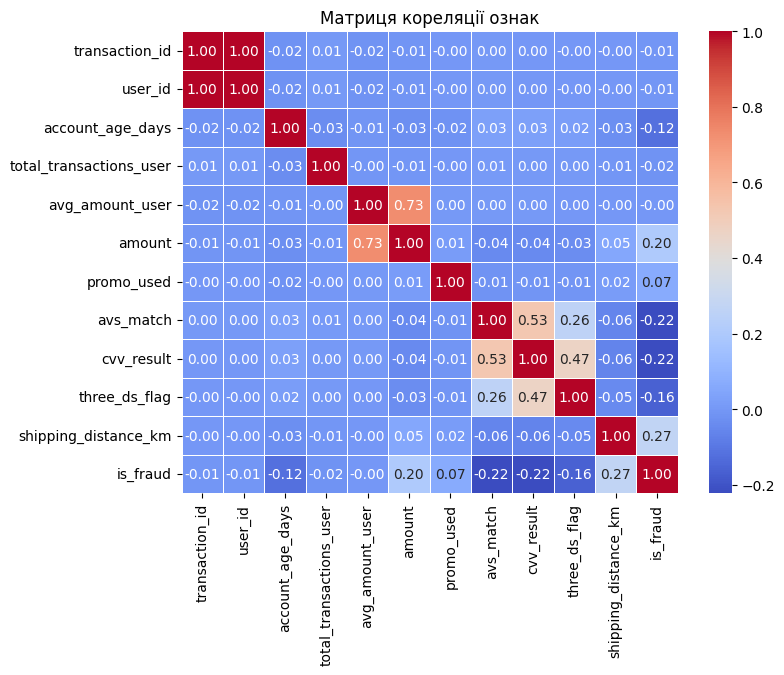

Кореляція ознак з шахрайством (is_fraud):
is_fraud                   1.000000
shipping_distance_km       0.270004
amount                     0.202499
promo_used                 0.067351
avg_amount_user           -0.001236
user_id                   -0.005294
transaction_id            -0.005295
total_transactions_user   -0.017093
account_age_days          -0.120340
three_ds_flag             -0.162160
cvv_result                -0.218982
avs_match                 -0.223299
Name: is_fraud, dtype: float64


In [45]:
# обчислення
corr_matrix = full_df.corr(numeric_only=True)

# візуалізація
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix,  annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

plt.title('Матриця кореляції ознак')
plt.show()

print("Кореляція ознак з шахрайством (is_fraud):")
print(corr_matrix['is_fraud'].sort_values(ascending=False))

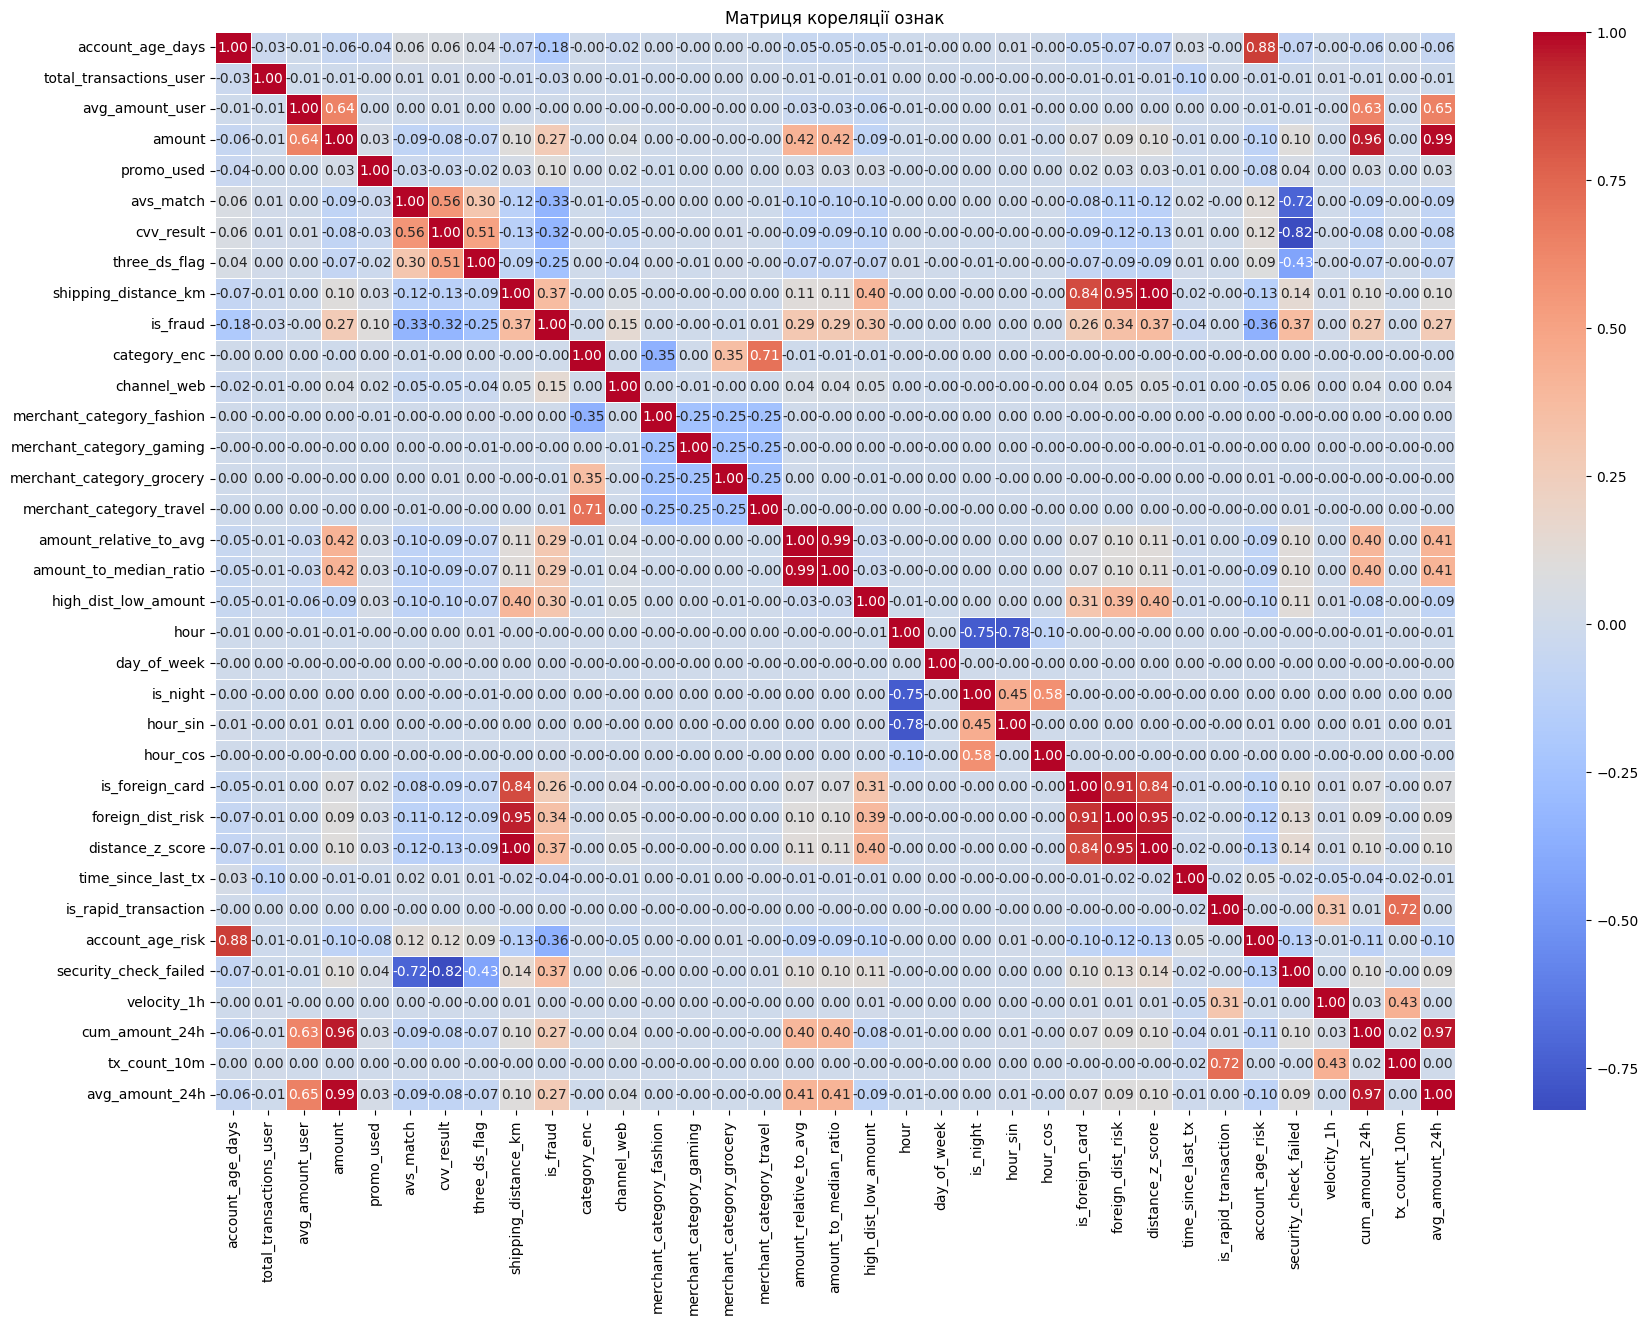

Кореляція ознак з шахрайством (is_fraud):
is_fraud                     1.000000
security_check_failed        0.372407
distance_z_score             0.368784
shipping_distance_km         0.368784
foreign_dist_risk            0.342476
high_dist_low_amount         0.303627
amount_relative_to_avg       0.289643
amount_to_median_ratio       0.288482
amount                       0.273599
avg_amount_24h               0.267904
cum_amount_24h               0.266750
is_foreign_card              0.263904
channel_web                  0.145789
promo_used                   0.102426
merchant_category_travel     0.006143
hour_cos                     0.004411
velocity_1h                  0.004261
is_night                     0.002574
hour_sin                     0.002362
merchant_category_fashion    0.001289
tx_count_10m                 0.000938
is_rapid_transaction         0.000530
day_of_week                  0.000240
category_enc                -0.001002
avg_amount_user             -0.001945
hour    

In [46]:
# обчислення
corr_matrix = df.corr()

# візуалізація
plt.figure(figsize=(20, 14))
sns.heatmap(corr_matrix,  annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

plt.title('Матриця кореляції ознак')
plt.show()

print("Кореляція ознак з шахрайством (is_fraud):")
print(corr_matrix['is_fraud'].sort_values(ascending=False))

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


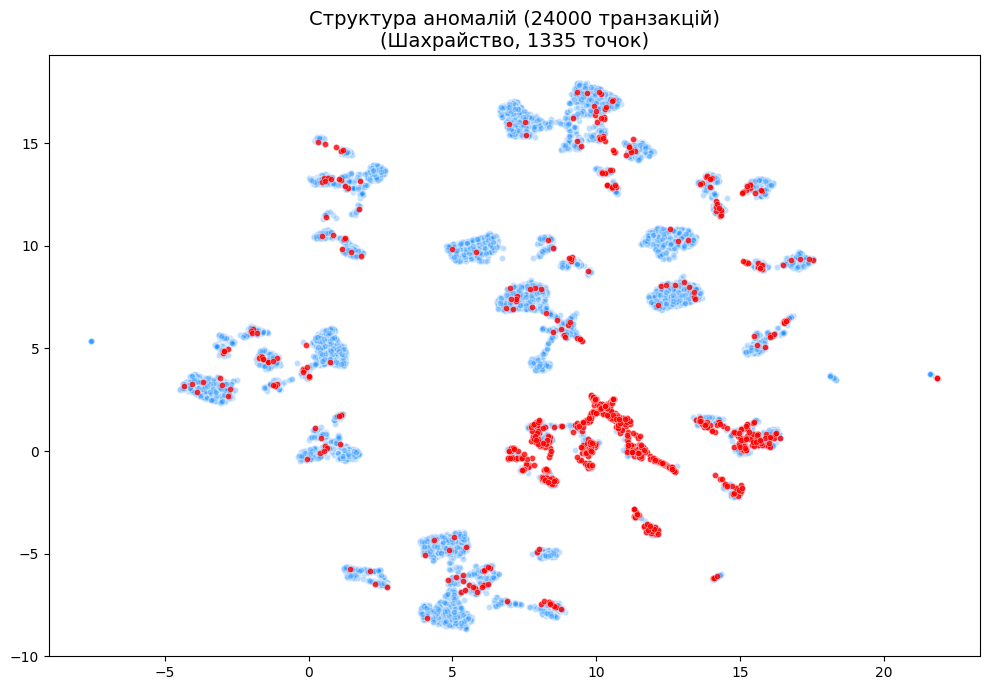

In [47]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42, metric='euclidean')

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

embedding = reducer.fit_transform(X_test_scaled)

# Візуалізація
plt.figure(figsize=(10, 7))

# Normal (y == 0)
plt.scatter(
    embedding[y_test == 0, 0],
    embedding[y_test == 0, 1],
    c='dodgerblue',
    s=20,
    alpha=0.3,
    label='Normal',
    edgecolors='white',
    rasterized=True
)

# Fraud (y == 1) поверх
plt.scatter(
    embedding[y_test == 1, 0],
    embedding[y_test == 1, 1],
    c='red',
    s=20,
    alpha=0.8,
    label='Fraud',
    edgecolors='white',
    linewidths=0.3,
    rasterized=True
)

# кількість шахрайства
fraud_count = np.sum(y_test == 1)

plt.title(f"Структура аномалій ({len(y_test)} транзакцій)\n"
          f"(Шахрайство, {fraud_count} точок)", fontsize=14)

plt.tight_layout()
plt.show()

/tmp/ipykernel_75025/4057671520.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Вплив', y='Ознака', data=lr_imp.head(5), palette=my_palette)


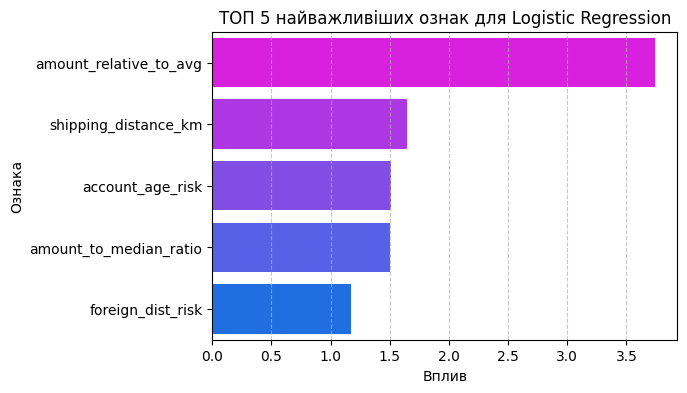

                      feature  importance
4      amount_relative_to_avg    3.743038
1        shipping_distance_km    1.647710
3        high_dist_low_amount    0.999583
21           account_age_days    0.946497
8                 channel_web    0.745420
6              cum_amount_24h    0.193793
9                  promo_used    0.177644
7             is_foreign_card    0.101640
10                       hour    0.037715
12                   is_night    0.037555
0       security_check_failed    0.035187
16                day_of_week    0.034712
13                   hour_sin    0.027686
15               tx_count_10m    0.007297
14  merchant_category_fashion   -0.011298
17   merchant_category_gaming   -0.014582
11                velocity_1h   -0.017753
20         time_since_last_tx   -0.031958
19  merchant_category_grocery   -0.058195
22                 cvv_result   -0.225105
18              three_ds_flag   -0.414749
23                  avs_match   -0.697218
2           foreign_dist_risk   -1

In [48]:
# Розрахунок важливості (абсолютні значення коефіцієнтів)
lr_imp = pd.DataFrame({
    'Ознака': a,
    'Вплив': np.abs(lr_model.coef_[0])
    }).sort_values(by='Вплив', ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(x='Вплив', y='Ознака', data=lr_imp.head(5), palette=my_palette)
plt.title('ТОП 5 найважливіших ознак для Logistic Regression')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# ваги ознак
feature_importance = pd.DataFrame({
    'feature': X_train_LR.columns,
    'importance': lr_model.coef_[0]
})
print(feature_importance.sort_values(by='importance', ascending=False))

/tmp/ipykernel_75025/3021118185.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Вплив', y='Ознака', data=pca_imp.head(5), palette=my_palette)


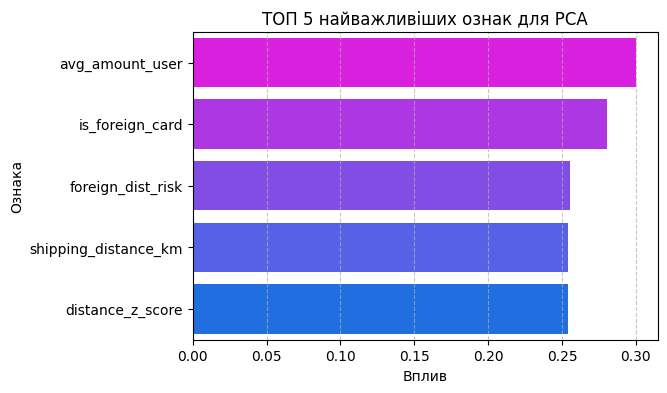

                       Ознака     Вплив
0             avg_amount_user  0.299851
1             is_foreign_card  0.280164
2           foreign_dist_risk  0.255545
3        shipping_distance_km  0.254373
4            distance_z_score  0.254373
5              avg_amount_24h  0.251438
6              cum_amount_24h  0.249403
7                      amount  0.247692
8        high_dist_low_amount  0.071825
9                        hour  0.016990
10                   hour_sin  0.015546
11                   is_night  0.014479
12           account_age_days  0.012114
13           account_age_risk  0.009852
14                 cvv_result  0.009566
15      security_check_failed  0.007621
16         time_since_last_tx  0.006684
17     amount_to_median_ratio  0.006246
18     amount_relative_to_avg  0.006120
19                   hour_cos  0.005522
20  merchant_category_fashion  0.004908
21   merchant_category_gaming  0.003858
22    total_transactions_user  0.003675
23   merchant_category_travel  0.002718


In [49]:
loadings = pd.DataFrame(
    np.abs(pca.components_.T),
    columns=['PC1', 'PC2'],
    index=b)

# середній вплив на обидві компоненти
loadings['Середній вплив'] = loadings.mean(axis=1)
pca_imp = loadings[['Середній вплив']].sort_values(by='Середній вплив', ascending=False).reset_index()
pca_imp.columns = ['Ознака', 'Вплив']

plt.figure(figsize=(6, 4))
sns.barplot(x='Вплив', y='Ознака', data=pca_imp.head(5), palette=my_palette)
plt.title('ТОП 5 найважливіших ознак для PCA')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(pca_imp)

/tmp/ipykernel_75025/1534645676.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Вплив', y='Ознака', data=dbscan_imp.head(5), palette=my_palette)


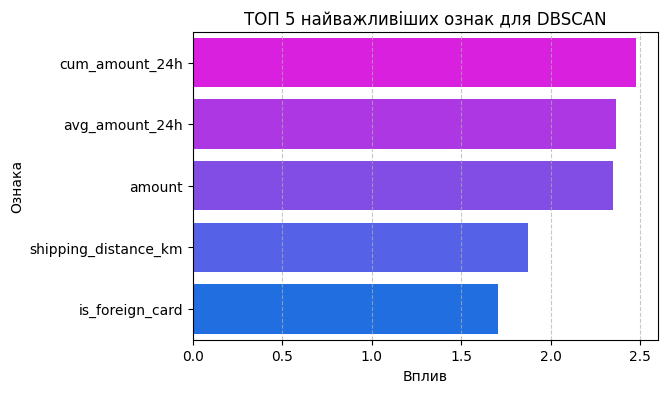

                    Ознака     Вплив
0           cum_amount_24h  2.474135
1           avg_amount_24h  2.366776
2                   amount  2.346911
3     shipping_distance_km  1.872909
4          is_foreign_card  1.703840
5     high_dist_low_amount  1.563348
6         account_age_risk  1.289224
7   amount_relative_to_avg  1.284837
8               cvv_result  1.094891
9                avs_match  1.090856
10           three_ds_flag  0.820563
11              promo_used  0.516975


In [50]:
X_test_db_df = pd.DataFrame(X_test_scaled_DB, columns=c)
X_test_db_df['db_pred'] = db_preds

dbscan_imp = X_test_db_df.groupby('db_pred').mean().diff().iloc[1].abs().sort_values(ascending=False).reset_index()
dbscan_imp.columns = ['Ознака', 'Вплив']

plt.figure(figsize=(6, 4))
sns.barplot(x='Вплив', y='Ознака', data=dbscan_imp.head(5), palette=my_palette)
plt.title('ТОП 5 найважливіших ознак для DBSCAN')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(dbscan_imp)

/tmp/ipykernel_75025/3865552958.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Вплив', y='Ознака', data=if_imp.head(5), palette=my_palette)


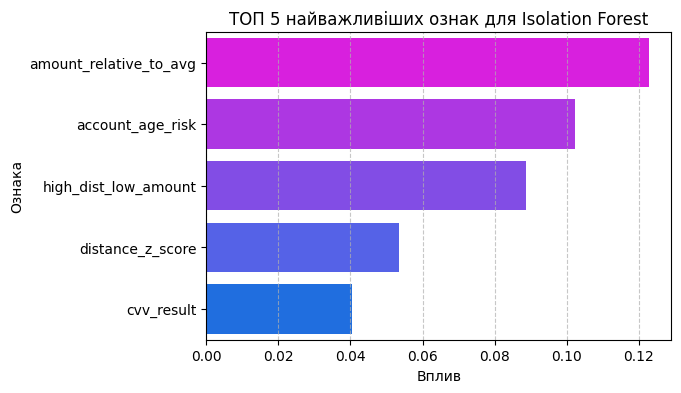

                   Ознака     Вплив
5  amount_relative_to_avg  0.122838
0        account_age_risk  0.102412
4    high_dist_low_amount  0.088640
3        distance_z_score  0.053414
2              cvv_result  0.040485
1               avs_match  0.028932
6    is_rapid_transaction  0.000000


In [51]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score

res = permutation_importance(iso_forest_final, X_test_scaled_IF, y_test, n_repeats=5, random_state=42,
                             scoring=lambda e, X, y: f1_score(y, e.predict(X) == -1))

if_imp = pd.DataFrame({
    'Ознака': d,
    'Вплив': res.importances_mean
    }).sort_values('Вплив', ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(x='Вплив', y='Ознака', data=if_imp.head(5), palette=my_palette)
plt.title('ТОП 5 найважливіших ознак для Isolation Forest')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(if_imp)

/tmp/ipykernel_75025/798472363.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Вплив', y='Ознака', data=xgb_imp.head(5), palette=my_palette)


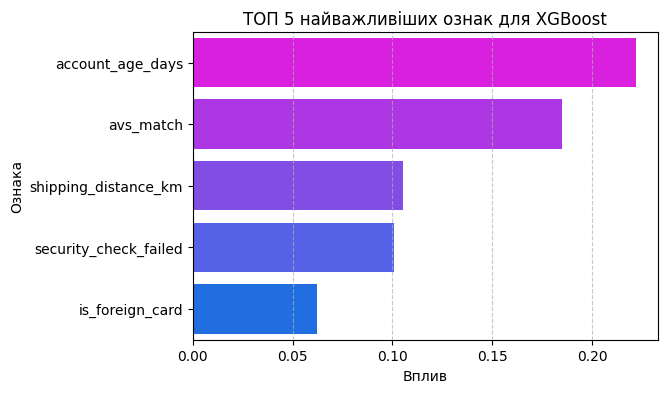

                       Ознака     Вплив
1            account_age_days  0.221826
2                   avs_match  0.185167
3        shipping_distance_km  0.105317
0       security_check_failed  0.100934
7             is_foreign_card  0.062276
6                      amount  0.051141
4               three_ds_flag  0.048853
5                  cvv_result  0.045275
8      amount_relative_to_avg  0.040645
9                 channel_web  0.032720
10          foreign_dist_risk  0.027104
11     amount_to_median_ratio  0.011103
12                 promo_used  0.008826
16             avg_amount_24h  0.006863
13             cum_amount_24h  0.005173
14   merchant_category_gaming  0.004336
18       high_dist_low_amount  0.004262
17    total_transactions_user  0.004120
22            avg_amount_user  0.003970
15                       hour  0.003938
27                velocity_1h  0.003664
20                   hour_cos  0.003597
21         time_since_last_tx  0.003579
19                   hour_sin  0.003542


In [52]:
xgb_imp = pd.DataFrame({
    'Ознака': xgb_model.feature_names_in_,  # Беремо ознаки, які "бачила" модель
    'Вплив': xgb_model.feature_importances_
}).sort_values(by='Вплив', ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(x='Вплив', y='Ознака', data=xgb_imp.head(5), palette=my_palette)
plt.title('ТОП 5 найважливіших ознак для XGBoost')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(xgb_imp)

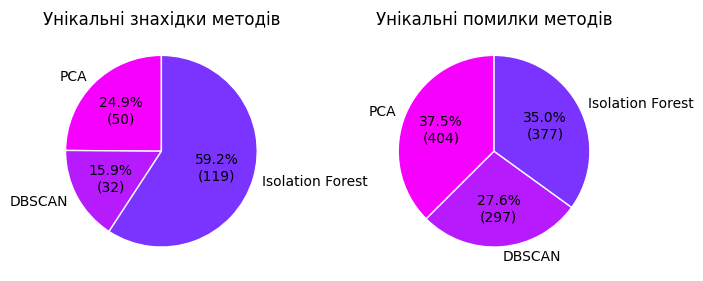

In [53]:
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        # відсоток (число)
        return f'{pct:.1f}%\n({val})'
    return my_autopct

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3))

# Унікальні знахідки
df_unique_tp = df_a[df_a['Унікальні знахідки']> 0]

ax1.pie(df_unique_tp['Унікальні знахідки'],
        labels=df_unique_tp['Метод'],
        autopct=make_autopct(df_unique_tp['Унікальні знахідки']),
        startangle=90,
        colors=my_palette,
        wedgeprops={'edgecolor': 'white'})
ax1.set_title('Унікальні знахідки методів')

# Унікальні помилки
df_unique_fp = df_a[df_a['Унікальні помилки']> 0]

ax2.pie(df_unique_fp['Унікальні помилки'],
        labels=df_unique_fp['Метод'],
        autopct=make_autopct(df_unique_fp['Унікальні помилки']),
        startangle=90,
        colors=my_palette,
        wedgeprops={'edgecolor': 'white'})
ax2.set_title('Унікальні помилки методів')

plt.tight_layout()
plt.show()

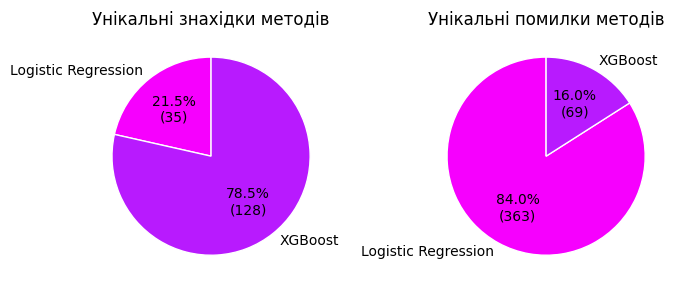

In [54]:
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        # відсоток (число)
        return f'{pct:.1f}%\n({val})'
    return my_autopct

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3))

# Унікальні знахідки
df_unique_tp = df_b[df_b['Унікальні знахідки']> 0]

ax1.pie(df_unique_tp['Унікальні знахідки'],
        labels=df_unique_tp['Метод'],
        autopct=make_autopct(df_unique_tp['Унікальні знахідки']),
        startangle=90,
        colors=my_palette,
        wedgeprops={'edgecolor': 'white'})
ax1.set_title('Унікальні знахідки методів')

# Унікальні помилки
df_unique_fp = df_b[df_b['Унікальні помилки']> 0]

ax2.pie(df_unique_fp['Унікальні помилки'],
        labels=df_unique_fp['Метод'],
        autopct=make_autopct(df_unique_fp['Унікальні помилки']),
        startangle=90,
        colors=my_palette,
        wedgeprops={'edgecolor': 'white'})
ax2.set_title('Унікальні помилки методів')

plt.tight_layout()
plt.show()

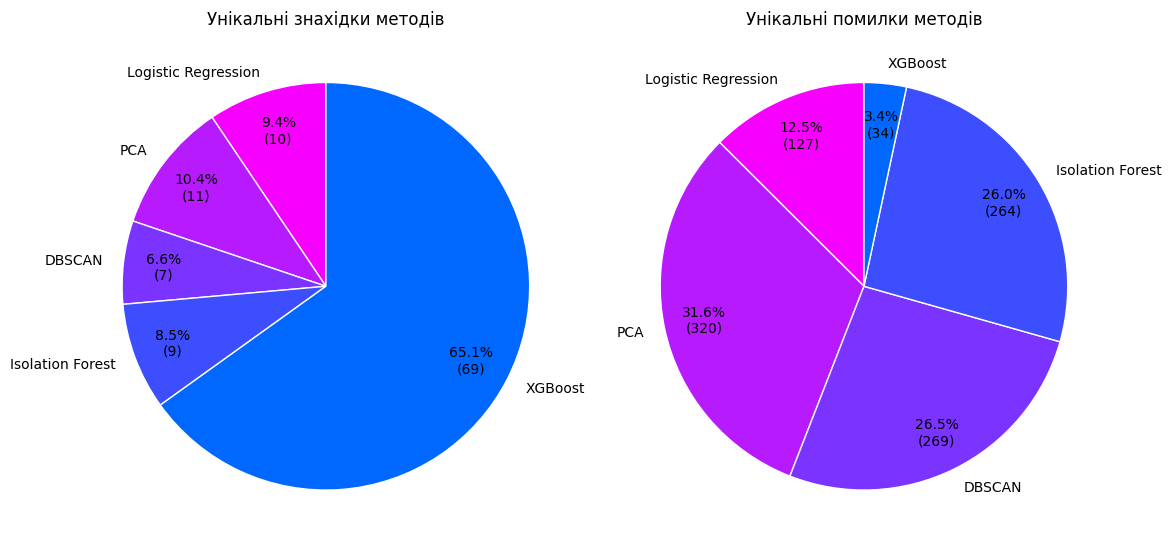

In [55]:
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        # відсоток (число)
        return f'{pct:.1f}%\n({val})'
    return my_autopct

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

# Унікальні знахідки
df_unique_tp = df_c[df_c['Унікальні знахідки']> 0]

ax1.pie(df_unique_tp['Унікальні знахідки'],
        labels=df_unique_tp['Метод'],
        autopct=make_autopct(df_unique_tp['Унікальні знахідки']),
        startangle=90,
        colors=my_palette,
        wedgeprops={'edgecolor': 'white'},
        pctdistance = 0.8)
ax1.set_title('Унікальні знахідки методів')

# Унікальні помилки
df_unique_fp = df_c[df_c['Унікальні помилки']> 0]

ax2.pie(df_unique_fp['Унікальні помилки'],
        labels=df_unique_fp['Метод'],
        autopct=make_autopct(df_unique_fp['Унікальні помилки']),
        startangle=90,
        colors=my_palette,
        wedgeprops={'edgecolor': 'white'},
        pctdistance = 0.8)
ax2.set_title('Унікальні помилки методів')

plt.tight_layout()
plt.show()